In [47]:
# import librairie utilisées
import pandas as pd
import seaborn as sbn
import matplotlib as mt
import matplotlib.pyplot as plt

#from pymongo import MongoClient


In [2]:
#import des données

dataset = pd.read_csv("healthcare_dataset.csv")


In [3]:
dataset.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## exploration des données :

In [4]:
# taille du dataset
dataset.shape

(55500, 15)

In [5]:
#informations generales
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [6]:
# Mise a jour des types Date of Admission & Discharge Date
dataset['Date of Admission'] = pd.to_datetime(dataset['Date of Admission'])
dataset['Discharge Date'] = pd.to_datetime(dataset['Discharge Date'])

In [7]:
#verification de la modification 
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                55500 non-null  object        
 1   Age                 55500 non-null  int64         
 2   Gender              55500 non-null  object        
 3   Blood Type          55500 non-null  object        
 4   Medical Condition   55500 non-null  object        
 5   Date of Admission   55500 non-null  datetime64[ns]
 6   Doctor              55500 non-null  object        
 7   Hospital            55500 non-null  object        
 8   Insurance Provider  55500 non-null  object        
 9   Billing Amount      55500 non-null  float64       
 10  Room Number         55500 non-null  int64         
 11  Admission Type      55500 non-null  object        
 12  Discharge Date      55500 non-null  datetime64[ns]
 13  Medication          55500 non-null  object    

In [ ]:
# Calcul des valeurs manquantes
dataset.isnull().sum()


Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [32]:
# Afficher les lignes en doublon
dataset.loc[
    dataset.duplicated(keep=False),
    :
]

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
64,Nancy glOVeR,58,Male,A-,Hypertension,2020-05-08,Jennifer Larson,"Khan, and Rodriguez Fischer",Medicare,19183.168885,378,Emergency,2020-06-01,Aspirin,Abnormal
107,DAVid higgInS,49,Female,B-,Arthritis,2021-03-05,Erin Henderson MD,"Evans and Hall Schneider,",Medicare,24948.477824,361,Emergency,2021-03-20,Penicillin,Abnormal
148,RoBErt hIGGInS,42,Male,AB-,Asthma,2021-05-06,Scott Davis,"and Ford Lee, Rodriguez",Medicare,13355.782085,451,Elective,2021-05-29,Ibuprofen,Inconclusive
154,kevIn HiCKs,66,Male,AB+,Arthritis,2021-06-23,Kelly Murphy,Robinson Inc,Medicare,1897.891727,196,Elective,2021-07-09,Ibuprofen,Abnormal
159,miCHAeL TayloR,29,Male,O-,Asthma,2020-02-27,Erica Mccormick,Donaldson-Frey,Medicare,41939.119937,453,Elective,2020-03-26,Ibuprofen,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55461,connOR coMPTon,63,Male,A+,Asthma,2021-08-21,Jonathan Allen,"and Willis Mullins, Bowers",Medicare,1936.702824,375,Emergency,2021-09-16,Paracetamol,Normal
55462,alYSsA mIlLER,35,Female,A-,Diabetes,2022-06-30,Ryan Price,Shelton-Gallagher,UnitedHealthcare,2210.460898,289,Elective,2022-07-27,Penicillin,Normal
55464,ChRIs huGHeS,35,Female,AB-,Obesity,2024-02-28,Katelyn Perry,Lyons-Hansen,Blue Cross,11889.154513,128,Emergency,2024-03-14,Paracetamol,Abnormal
55484,keNNEtH alvarez,80,Male,O+,Cancer,2022-05-05,Andrew Conner,Sons Mayo and,Cigna,45653.802310,114,Elective,2022-05-17,Aspirin,Normal


In [41]:
# suppression des doublons
dataset = dataset.drop_duplicates()
dataset.shape

(54966, 15)

In [ ]:
# mise en forme des Noms des patients
dataset["Name"] = dataset["Name"].str.title()
dataset.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


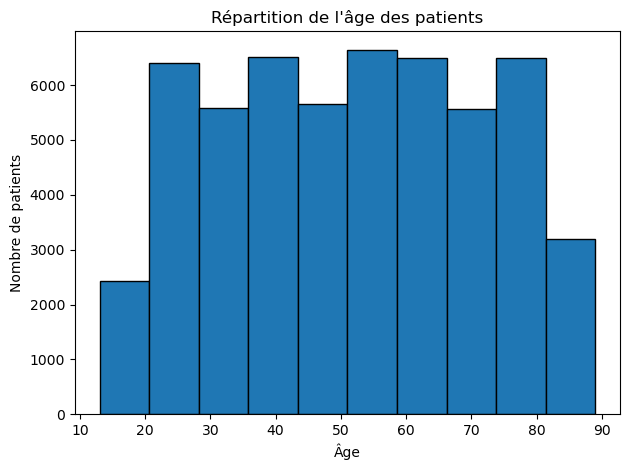

In [ ]:
#Répartition de l'âge des patients

dataset["Age"].plot(
    kind="hist",
    bins=10,
    edgecolor="black"
)

plt.title("Répartition de l'âge des patients")
plt.xlabel("Âge")
plt.ylabel("Nombre de patients")
plt.tight_layout()
plt.show()

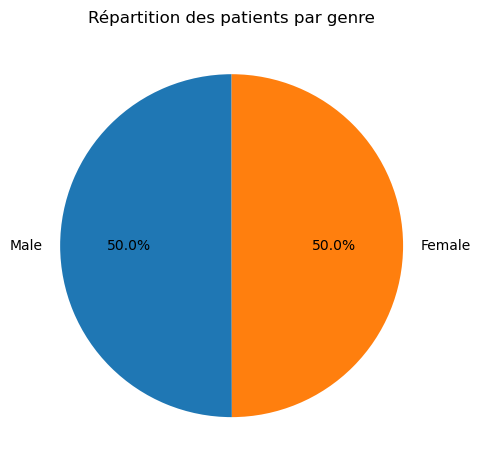

In [49]:
# Compter le nombre de patients par genre
repartition_genre = dataset["Gender"].value_counts()

# Créer le graphique en camembert
repartition_genre.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des patients par genre")
plt.ylabel("")  # Masquer le nom de la colonne sur le côté
plt.tight_layout()
plt.show()